In [57]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler, RobustScaler, MinMaxScaler, LabelEncoder, OneHotEncoder, OrdinalEncoder
from sklearn.model_selection import train_test_split
from category_encoders import TargetEncoder
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error, mean_squared_error

In [58]:
df = pd.read_csv("CarPrice_Assignment.csv")

In [59]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    str    
 3   fueltype          205 non-null    str    
 4   aspiration        205 non-null    str    
 5   doornumber        205 non-null    str    
 6   carbody           205 non-null    str    
 7   drivewheel        205 non-null    str    
 8   enginelocation    205 non-null    str    
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    str    
 15  cylindernumber    205 non-null    str    
 16  enginesize        205 non-null    int64  
 17  fuelsyst

In [60]:
df

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,201,-1,volvo 145e (sw),gas,std,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,9.5,114,5400,23,28,16845.0
201,202,-1,volvo 144ea,gas,turbo,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,8.7,160,5300,19,25,19045.0
202,203,-1,volvo 244dl,gas,std,four,sedan,rwd,front,109.1,...,173,mpfi,3.58,2.87,8.8,134,5500,18,23,21485.0
203,204,-1,volvo 246,diesel,turbo,four,sedan,rwd,front,109.1,...,145,idi,3.01,3.40,23.0,106,4800,26,27,22470.0


In [61]:
# Assigning X and y
X = df.drop(columns=["price","CarName",'car_ID'])
y = df['price']

In [62]:
# separating number columns and object columns 
num_cols = X.select_dtypes(include="number").columns
obj_cols = X.select_dtypes(include='object').columns

C:\Users\Test\AppData\Local\Temp\ipykernel_13340\664949596.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  obj_cols = X.select_dtypes(include='object').columns


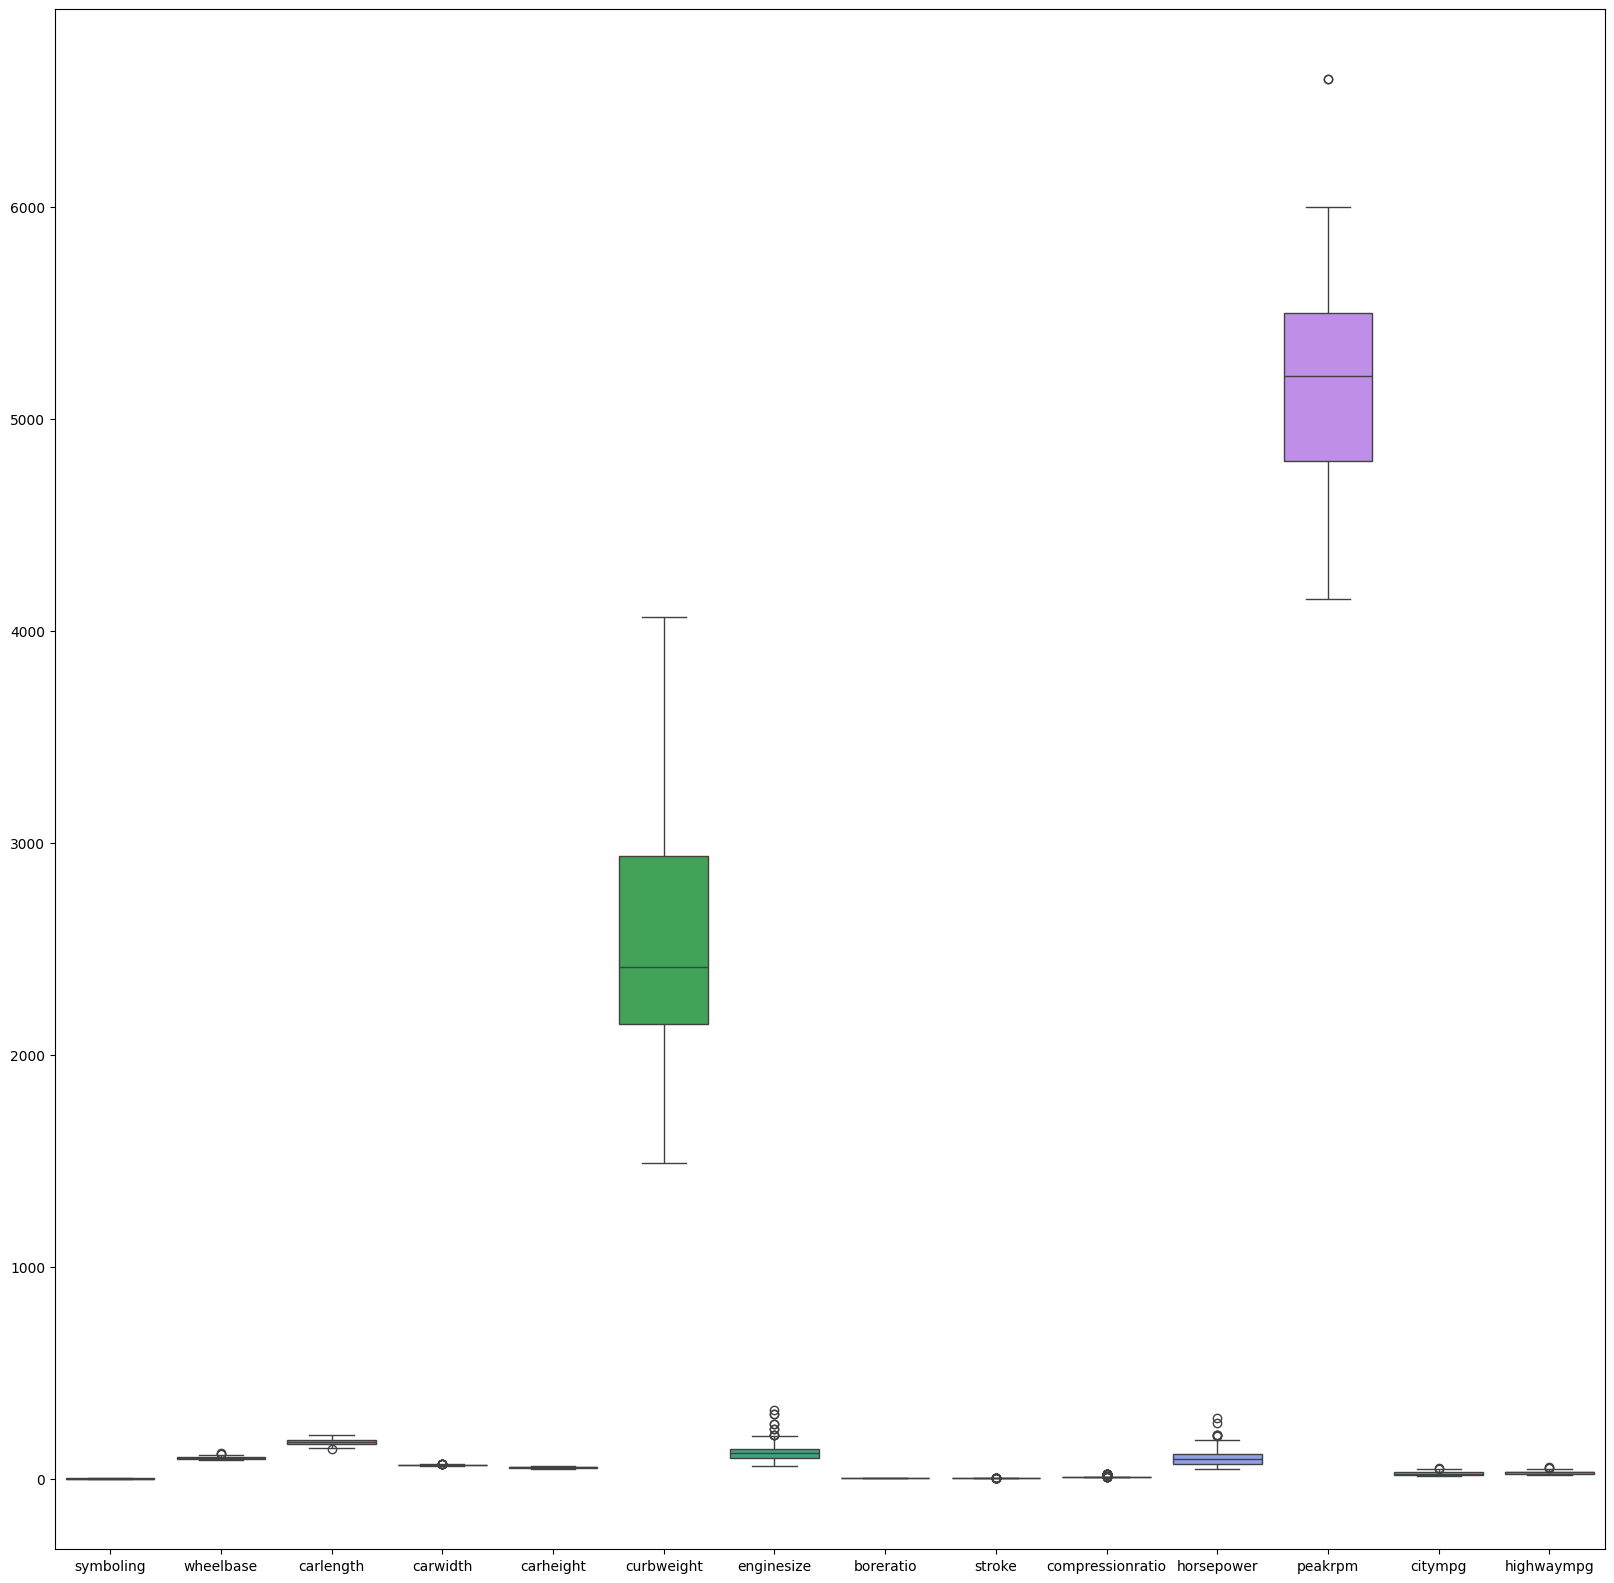

In [63]:
# checking for outliers
plt.figure(figsize=(20,20))
sns.boxplot(X[num_cols])
plt.show()

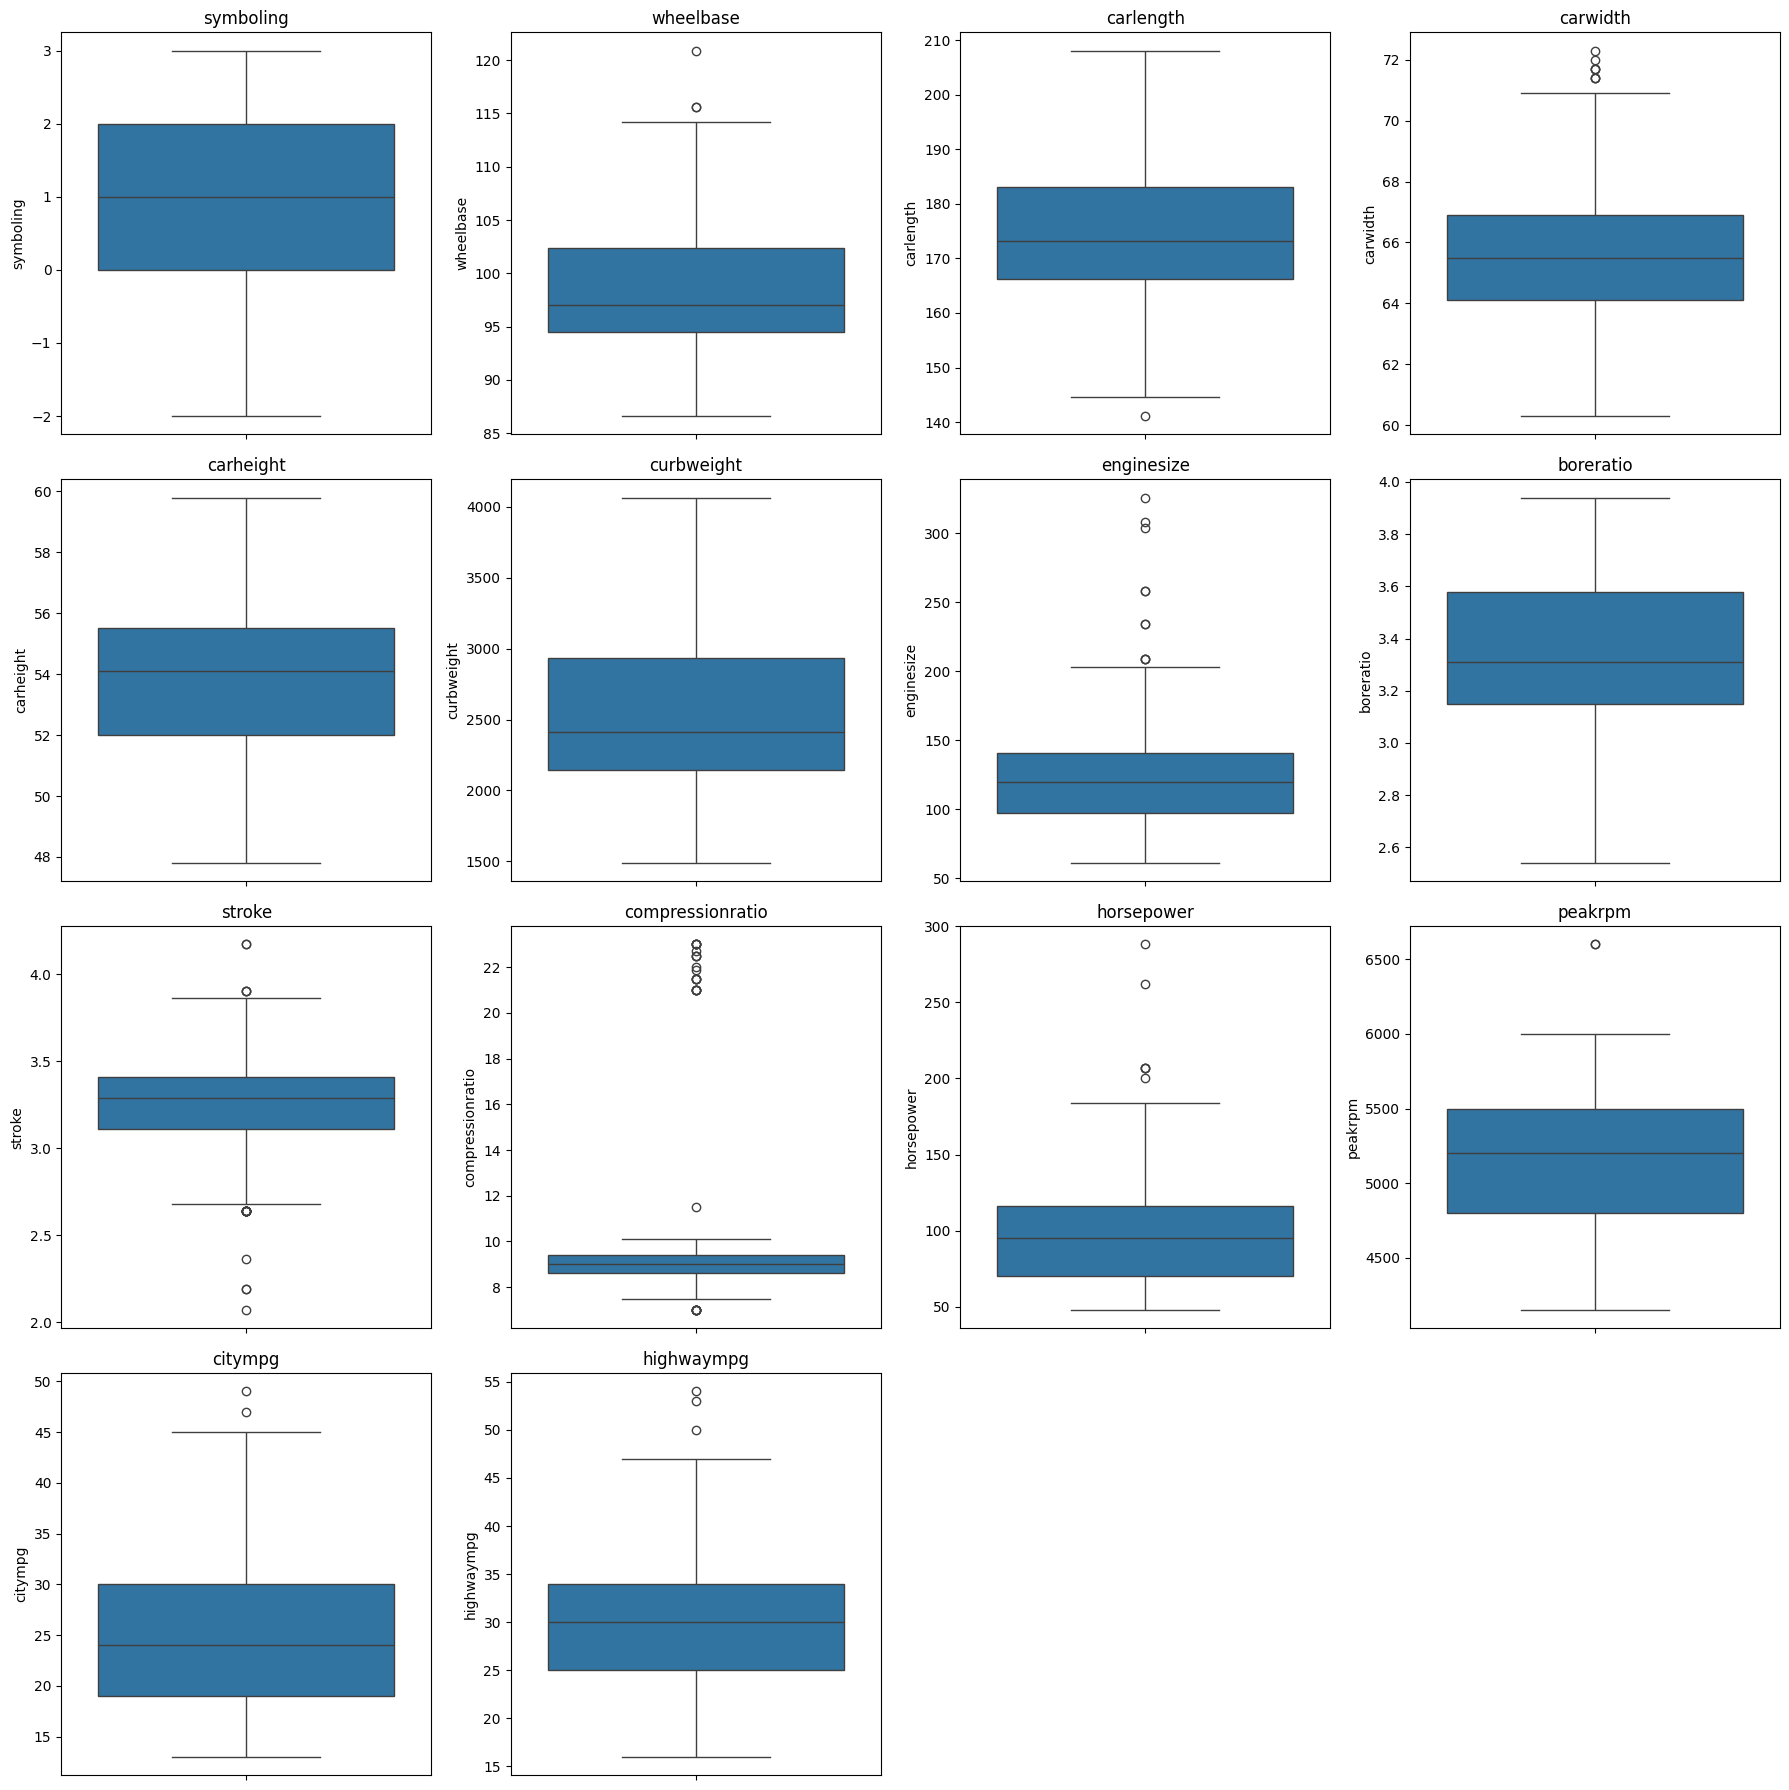

In [64]:
plt.figure(figsize=(18,18))
for i, col in enumerate(num_cols):
    plt.subplot(4,4,i+1)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()

In [65]:
xtrain, xtest, ytrain, ytest = train_test_split(X, y, train_size=0.8, random_state=42)

In [66]:
X[obj_cols].nunique()

fueltype          2
aspiration        2
doornumber        2
carbody           5
drivewheel        3
enginelocation    2
enginetype        7
cylindernumber    7
fuelsystem        8
dtype: int64

# MinMaxScaler

In [67]:
min_scaling = MinMaxScaler()
xtrain[num_cols] = min_scaling.fit_transform(xtrain[num_cols])
xtrain

,symboling,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,carwidth,...,cylindernumber,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg
66,0.4,diesel,std,four,sedan,rwd,front,0.631034,0.524138,0.409524,...,four,0.250000,idi,0.635714,0.747619,0.93750,0.084746,0.020408,0.56250,0.676471
111,0.4,gas,std,four,sedan,rwd,front,0.734483,0.725862,0.628571,...,four,0.195312,mpfi,0.657143,0.057143,0.08750,0.182203,0.346939,0.18750,0.235294
153,0.4,gas,std,four,wagon,fwd,front,0.313793,0.432759,0.171429,...,four,0.085938,2bbl,0.364286,0.457143,0.12500,0.042373,0.265306,0.56250,0.617647
96,0.6,gas,std,four,sedan,fwd,front,0.272414,0.356897,0.190476,...,four,0.105469,2bbl,0.435714,0.580952,0.15000,0.072034,0.428571,0.56250,0.617647
38,0.4,gas,std,two,hatchback,fwd,front,0.341379,0.394828,0.323810,...,four,0.156250,1bbl,0.435714,0.719048,0.12500,0.144068,0.673469,0.43750,0.500000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,0.6,gas,std,two,hatchback,rwd,front,0.434483,0.584483,0.580952,...,six,0.433594,mpfi,0.635714,0.571429,0.12500,0.457627,0.428571,0.18750,0.264706
14,0.6,gas,std,four,sedan,rwd,front,0.582759,0.765517,0.485714,...,six,0.367188,mpfi,0.550000,0.533333,0.12500,0.292373,0.040816,0.21875,0.264706
92,0.6,gas,std,four,sedan,fwd,front,0.272414,0.356897,0.190476,...,four,0.105469,2bbl,0.435714,0.580952,0.15000,0.072034,0.428571,0.56250,0.617647
179,1.0,gas,std,two,hatchback,rwd,front,0.562069,0.670690,0.561905,...,six,0.394531,mpfi,0.521429,0.609524,0.14375,0.461864,0.428571,0.18750,0.235294


In [68]:
df.select_dtypes(include='number').corr()

,car_ID,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
car_ID,1.000000,-0.151621,0.129729,0.170636,0.052387,0.255960,0.071962,-0.033930,0.260064,-0.160824,0.150276,-0.015006,-0.203789,0.015940,0.011255,-0.109093
symboling,-0.151621,1.000000,-0.531954,-0.357612,-0.232919,-0.541038,-0.227691,-0.105790,-0.130051,-0.008735,-0.178515,0.070873,0.273606,-0.035823,0.034606,-0.079978
wheelbase,0.129729,-0.531954,1.000000,0.874587,0.795144,0.589435,0.776386,0.569329,0.488750,0.160959,0.249786,0.353294,-0.360469,-0.470414,-0.544082,0.577816
carlength,0.170636,-0.357612,0.874587,1.000000,0.841118,0.491029,0.877728,0.683360,0.606454,0.129533,0.158414,0.552623,-0.287242,-0.670909,-0.704662,0.682920
carwidth,0.052387,-0.232919,0.795144,0.841118,1.000000,0.279210,0.867032,0.735433,0.559150,0.182942,0.181129,0.640732,-0.220012,-0.642704,-0.677218,0.759325
carheight,0.255960,-0.541038,0.589435,0.491029,0.279210,1.000000,0.295572,0.067149,0.171071,-0.055307,0.261214,-0.108802,-0.320411,-0.048640,-0.107358,0.119336
curbweight,0.071962,-0.227691,0.776386,0.877728,0.867032,0.295572,1.000000,0.850594,0.648480,0.168790,0.151362,0.750739,-0.266243,-0.757414,-0.797465,0.835305
enginesize,-0.033930,-0.105790,0.569329,0.683360,0.735433,0.067149,0.850594,1.000000,0.583774,0.203129,0.028971,0.809769,-0.244660,-0.653658,-0.677470,0.874145
boreratio,0.260064,-0.130051,0.488750,0.606454,0.559150,0.171071,0.648480,0.583774,1.000000,-0.055909,0.005197,0.573677,-0.254976,-0.584532,-0.587012,0.553173
stroke,-0.160824,-0.008735,0.160959,0.129533,0.182942,-0.055307,0.168790,0.203129,-0.055909,1.000000,0.186110,0.080940,-0.067964,-0.042145,-0.043931,0.079443


In [69]:
le_fueltype = LabelEncoder()
le_aspiration = LabelEncoder()
le_doornumber = LabelEncoder()
le_enginelocation = LabelEncoder()
le_cylindernumber = LabelEncoder()

In [70]:
xtrain['fueltype'] = le_fueltype.fit_transform(xtrain['fueltype'])
xtest['fueltype'] = le_fueltype.transform(xtest['fueltype'])

xtrain['aspiration'] = le_aspiration.fit_transform(xtrain['aspiration'])
xtest['aspiration'] = le_aspiration.transform(xtest['aspiration'])

xtrain['doornumber'] = le_doornumber.fit_transform(xtrain['doornumber'])
xtest['doornumber'] = le_doornumber.transform(xtest['doornumber'])

xtrain['enginelocation'] = le_enginelocation.fit_transform(xtrain['enginelocation'])
xtest['enginelocation'] = le_enginelocation.transform(xtest['enginelocation'])



In [83]:
ohe_cols = ['carbody', 'drivewheel', 'enginetype', 'fuelsystem', 'cylindernumber']

ohe = OneHotEncoder( sparse_output=False, handle_unknown='ignore')

updated_xtrain = ohe.fit_transform(xtrain[ohe_cols])
updated_xtest = ohe.transform(xtest[ohe_cols])

In [81]:
print(xtrain.select_dtypes(include='object').columns)

Index(['carbody', 'drivewheel', 'enginetype', 'cylindernumber', 'fuelsystem'], dtype='str')


C:\Users\Test\AppData\Local\Temp\ipykernel_13340\2939358856.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(xtrain.select_dtypes(include='object').columns)


In [84]:
model = LinearRegression()
model.fit(updated_xtrain, ytrain)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [85]:
model.score(updated_xtrain, ytrain)

0.8169145056410921

In [86]:
model.score(updated_xtest, ytest)

0.7528954396503731